# Outlier Patch Detection on TR1 Data

Applies the per-patch amplitude perturbation analysis from `outlier_patch_test.ipynb`
to the first TR1 shear map (`SHE-1`).  The 48-patch tile mask serves as both the
patch decomposition and the jackknife regions.

In [57]:
import os
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from scipy.stats import chi2 as chi2_dist

import heracles
import heracles.healpy
import heracles.dices as dices


## 1. Load catalog and build shear maps

We read `23405.fits` with `heracles.FitsCatalog` and select tomographic bin 1.
The shear (SHE) and weight (WHT) maps are produced by `heracles.map_catalogs`
using the LensMC ellipticity columns (`she_lensmc_e1/e2/weight`).

In [58]:
from heracles.core import update_metadata

DATA_DIR          = "tr1_data"
DATA_PRODUCTS_DIR = "data_products"
CAT_FILE  = f"{DATA_DIR}/23405.fits"

nside     = 2048
lmax_data = 4000
lmax_mask = 6000
lmax_out  = 2000
lmin      = 500
nlbins    = 10
methods   = ["lensmc"]  # both shear estimators
bins      = [0] #list(range(7))          # 0 = full catalog, 1-6 = tomo bins

mask = hp.read_map("/home/jaimerzp/Documents/software/heracles/examples/tr1_data/tr1_mask.fits")
mask = hp.ud_grade(mask, nside_out=nside)

catalog  = heracles.FitsCatalog(CAT_FILE)
catalog.visibility = mask
catalogs = {0: catalog[f"tom_bin_id != -1"]}  # full catalog
# Switch off the tomographic binning for now, to increase the S/N of the maps and avoid outliers in the low-z bins
#for i in range(1, 7):
#    catalogs[i] = catalog[f"tom_bin_id == {i}"]

mapper_data = heracles.healpy.HealpixMapper(nside=nside, lmax=lmax_data)
mapper_mask = heracles.healpy.HealpixMapper(nside=nside, lmax=lmax_mask)

# Create data-products directory tree
os.makedirs(DATA_PRODUCTS_DIR, exist_ok=True)
for method in methods:
    os.makedirs(f"{DATA_PRODUCTS_DIR}/{method}", exist_ok=True)

she_maps_all = {}
wht_maps_all = {}

for method in methods:
    cache_file = f"{DATA_PRODUCTS_DIR}/{method}/maps_nside_{nside}.fits"

    if os.path.exists(cache_file):
        maps = heracles.read_maps(cache_file)
        she_maps_all[method] = {k: maps[k] for k in maps if k[0] == "SHE"}
        wht_maps_all[method] = {k: maps[k] for k in maps if k[0] == "WHT"}
        print(f"  Loaded maps [{method}] from cache")
    else:
        fields_she = {
            "SHE": heracles.Shears(
                mapper_data,
                "right_ascension",
                "declination",
                f"she_{method}_e1",
                f"-she_{method}_e2",
                f"she_{method}_weight",
                mask="WHT",
            ),
        }
        fields_wht = {
            "WHT": heracles.Weights(
                mapper_mask,
                "right_ascension",
                "declination",
                f"she_{method}_weight",
            ),
        }
        she_maps_all[method] = heracles.map_catalogs(fields_she, catalogs)
        wht_maps_all[method] = heracles.map_catalogs(fields_wht, catalogs)
        heracles.write_maps(cache_file, {**she_maps_all[method], **wht_maps_all[method]}, clobber=True)
        print(f"  Mapped and cached [{method}]  ({len(bins)} bins)")

print(f"Data-products dir: {DATA_PRODUCTS_DIR}/")


  Loaded maps [lensmc] from cache
Data-products dir: data_products/


## 2. Build the patch segmentation map

We divide the survey footprint into roughly 20-sq-deg patches using
`skysegmentor.segmentmapN` on the WHT weight map.

In [59]:
import skysegmentor

# Per-method, per-bin bias from metadata
b_all = {
    method: {
        ibin: she_maps_all[method][("SHE", ibin)].dtype.metadata["bias"]
        for ibin in bins
    }
    for method in methods
}

# Patch layout is method- and bin-independent
fsky      = mask.sum() / hp.nside2npix(nside)
area_deg2 = fsky * 4 * np.pi * (180 / np.pi) ** 2
n_patches = max(1, round(area_deg2 / 20))
print(f"Survey area: {area_deg2:.1f} sq deg  \u2192  {n_patches} patches of ~{area_deg2/n_patches:.1f} sq deg each")

jkmap = skysegmentor.segmentmapN(mask, n_patches)
hp.write_map(f"{DATA_PRODUCTS_DIR}/jkmap_npatches_{n_patches}_nside_{nside}.fits", jkmap, overwrite=True)
print(f"jkmap unique labels: {np.unique(jkmap[jkmap > 0]).astype(int)}")


Survey area: 504.5 sq deg  →  25 patches of ~20.2 sq deg each


setting the output map dtype to [dtype('float64')]


jkmap unique labels: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25]


/tmp/ipykernel_16380/1235972990.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  lon_c, lat_c = float(lon_c), float(lat_c)
/tmp/ipykernel_16380/1235972990.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


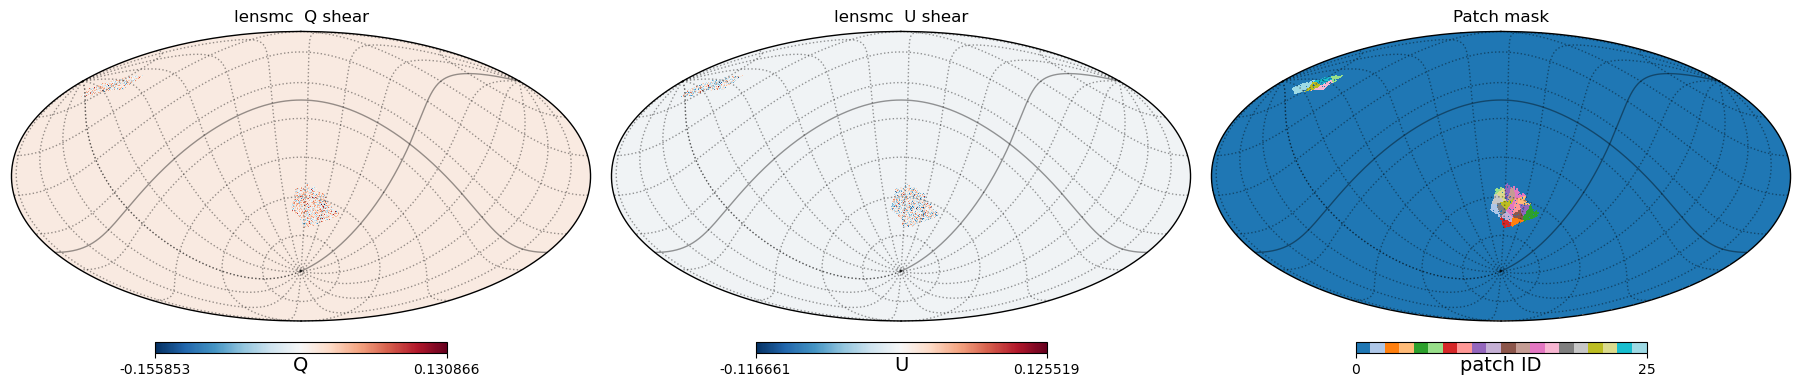

In [60]:
# ── Diagnostic: SHE-1 maps for both methods + patch regions ──
footprint_pix = np.where(she_maps_all["lensmc"][("SHE", 0)][0] != 0)[0]
vec = np.array(hp.pix2vec(nside, footprint_pix))
centre_vec = vec.mean(axis=1)
centre_vec /= np.linalg.norm(centre_vec)
lon_c, lat_c = hp.vec2ang(centre_vec, lonlat=True)
lon_c, lat_c = float(lon_c), float(lat_c)

fig = plt.figure(figsize=(18, 8))

for row, method in enumerate(methods):
    she_m = she_maps_all[method]
    hp.mollview(
        she_m[("SHE", 0)][0], fig=fig, sub=(2, 3, row * 3 + 1),
        rot=(lon_c, lat_c, 0),
        title=f"{method}  Q shear", unit="Q",
        cmap="RdBu_r", notext=True,
    )
    hp.mollview(
        she_m[("SHE", 0)][1], fig=fig, sub=(2, 3, row * 3 + 2),
        rot=(lon_c, lat_c, 0),
        title=f"{method}  U shear", unit="U",
        cmap="RdBu_r", notext=True,
    )
    hp.mollview(
        jkmap, fig=fig, sub=(2, 3, row * 3 + 3),
        rot=(lon_c, lat_c, 0),
        title="Patch mask", unit="patch ID",
        cmap="tab20", notext=True,
    )

hp.graticule(dpar=5, dmer=5, alpha=0.4)
plt.tight_layout()
plt.show()


## 3. Heracles setup

In [61]:
# Per-patch and full-footprint naturalspice: SHE @ lmax_data, WHT @ lmax_mask
fields = {
    "SHE": heracles.Shears(mapper_data, mask="WHT"),
    "WHT": heracles.Weights(mapper_data),
}
print(f"Data mapper: nside={mapper_data.nside}, lmax={mapper_data.lmax}")
print(f"Mask mapper: nside={mapper_mask.nside}, lmax={mapper_mask.lmax}")

Data mapper: nside=2048, lmax=4000
Mask mapper: nside=2048, lmax=6000


## 4. Per-patch alms and pseudo-$C_\ell$

For each patch we:
1. Mask the shear and weight maps to that patch's pixels
2. Transform to alms
3. Compute the pseudo-$C_\ell$

In [62]:
import heracles.dices as dices

# Nested dicts: [method][label][ibin]
# patch_data_alms and patch_mask_alms are cached to disk and reused in section 9
all_data_cls    = {method: {label: {} for label in range(1, n_patches + 1)} for method in methods}
all_mask_cls    = {method: {label: {} for label in range(1, n_patches + 1)} for method in methods}
patch_data_alms = {method: {ibin: {} for ibin in bins} for method in methods}
patch_mask_alms = {method: {ibin: {} for ibin in bins} for method in methods}

for method in methods:
    for label in range(1, n_patches + 1):
        cls_cache  = f"{DATA_PRODUCTS_DIR}/{method}/pseudo_cls_patch_{label:03d}_lmax{lmax_data}.fits"
        alms_cache = f"{DATA_PRODUCTS_DIR}/{method}/alms_patch_{label:03d}_lmax{lmax_data}.fits"
        patch_pix  = jkmap == label

        if os.path.exists(alms_cache):
            # heracles.read_alms restores dtype metadata (including spin) from FITS
            alms_data = heracles.read_alms(alms_cache)
            for ibin in bins:
                patch_data_alms[method][ibin][label] = alms_data[("SHE", ibin)]
                patch_mask_alms[method][ibin][label] = alms_data[("WHT", ibin)]
        else:
            # Compute per-patch alms and cache them
            alms_out = {}
            for ibin in bins:
                she = she_maps_all[method][("SHE", ibin)]
                wht = wht_maps_all[method][("WHT", ibin)]
                b   = b_all[method][ibin]

                she_p = she.copy(); she_p[:, ~patch_pix] = 0.0
                wht_p = wht.copy(); wht_p[~patch_pix]    = 0.0
                update_metadata(she_p, fsky=fsky/n_patches, bias=b/n_patches)

                patch_data_alms[method][ibin][label] = mapper_data.transform(she_p)
                patch_mask_alms[method][ibin][label] = mapper_mask.transform(wht_p)
                alms_out[("SHE", ibin)] = patch_data_alms[method][ibin][label]
                alms_out[("WHT", ibin)] = patch_mask_alms[method][ibin][label]
            heracles.write_alms(alms_cache, alms_out, clobber=True)

        if os.path.exists(cls_cache):
            # Load pseudo-Cls from cache
            combined = heracles.read(cls_cache)
            for ibin in bins:
                all_data_cls[method][label][ibin] = {("SHE", "SHE", ibin, ibin): combined[("SHE", "SHE", ibin, ibin)]}
                all_mask_cls[method][label][ibin] = {("WHT", "WHT", ibin, ibin): combined[("WHT", "WHT", ibin, ibin)]}
        else:
            # Compute pseudo-Cls from alms and cache them
            combined = {}
            for ibin in bins:
                all_data_cls[method][label][ibin] = heracles.angular_power_spectra(
                    {("SHE", ibin): patch_data_alms[method][ibin][label]})
                all_mask_cls[method][label][ibin] = heracles.angular_power_spectra(
                    {("WHT", ibin): patch_mask_alms[method][ibin][label]})
                combined.update(all_data_cls[method][label][ibin])
                combined.update(all_mask_cls[method][label][ibin])
            heracles.write(cls_cache, combined, clobber=True)

        if label % 5 == 0 or label == n_patches:
            print(f"  [{method}] patch {label}/{n_patches}", end=", ", flush=True)
    print("done.")


  [lensmc] patch 5/25,   [lensmc] patch 10/25,   [lensmc] patch 15/25,   [lensmc] patch 20/25,   [lensmc] patch 25/25, done.


## 5. Unmix the Cls of each region

`naturalspice` divides the data correlation function by the mask correlation
function in real space, correcting for mode-mixing without an explicit
mixing-matrix inversion.

In [63]:
ell_data = np.arange(0, lmax_data + 1)
ell_out  = np.arange(0, lmax_out + 1)
ledges = np.logspace(np.log10(lmin), np.log10(lmax_out), nlbins + 1)
lgrid = 0.5 * (ledges[:-1] + ledges[1:])

In [64]:
from heracles.unmixing import _naturalspice, logistic
try:
    from copy import replace
except ImportError:
    from dataclasses import replace

rcond     = 0.7
k         = 130.0
rcond_str = f"rcond{rcond:.0e}".replace("e-0", "e-").replace("e+0", "e+")

all_corrf          = {method: {label: {} for label in range(1, n_patches + 1)} for method in methods}
all_unmixed_binned = {method: {label: {} for label in range(1, n_patches + 1)} for method in methods}

print(f"Two-step naturalspice  (rcond={rcond}, k={k}) ...")
for method in methods:
    for label in range(1, n_patches + 1):
        corrf_file = f"{DATA_PRODUCTS_DIR}/{method}/corrf_patch_lmax_{lmax_out}_{label:03d}_rcond_{rcond_str}_k_{k:.1f}.fits"
        cls_file   = f"{DATA_PRODUCTS_DIR}/{method}/decoupled_cls_patch_lmax_{lmax_out}_{label:03d}_rcond_{rcond_str}_k_{k:.1f}.fits"

        if os.path.exists(corrf_file) and os.path.exists(cls_file):
            corrf_data = heracles.read(corrf_file)
            cls_data   = heracles.read(cls_file)
            for ibin in bins:
                key = ("SHE", "SHE", ibin, ibin)
                all_corrf[method][label][ibin]          = corrf_data[key]
                all_unmixed_binned[method][label][ibin] = cls_data[key]
        else:
            corrf_out, cls_out = {}, {}
            for ibin in bins:
                data = all_data_cls[method][label][ibin]
                mask = all_mask_cls[method][label][ibin]
                key  = ("SHE", "SHE", ibin, ibin)

                wd = heracles.cl2corr(heracles.binned(data, np.arange(0, lmax_mask + 2)))
                wm = heracles.cl2corr(mask)
                for m_key in list(wm.keys()):
                    a = wm[m_key].array
                    wm[m_key] = replace(wm[m_key], array=a * logistic(np.log10(abs(a)), x0=np.log10(rcond * a.max()), k=k))

                corrf     = _naturalspice(wd, wm, fields)
                unmixed   = heracles.binned(heracles.corr2cl(corrf), np.arange(0, lmax_out + 1))
                binned_cl = heracles.binned(unmixed, ledges)

                all_corrf[method][label][ibin]          = corrf[key]
                all_unmixed_binned[method][label][ibin] = binned_cl[key]
                corrf_out[key] = corrf[key]
                cls_out[key]   = binned_cl[key]

            heracles.write(corrf_file, corrf_out, clobber=True)
            heracles.write(cls_file,   cls_out,   clobber=True)

        if label % 5 == 0 or label == n_patches:
            print(f"  [{method}] patch {label}/{n_patches}", end=", ", flush=True)
    print("done.")


Two-step naturalspice  (rcond=0.7, k=130.0) ...
  [lensmc] patch 5/25,   [lensmc] patch 10/25,   [lensmc] patch 15/25,   [lensmc] patch 20/25,   [lensmc] patch 25/25, done.


## 6. Full-footprint $C_\ell$

The full-footprint alm is the sum of per-patch alms (SHT linearity — no extra SHTs).
The covariance is the **sample covariance** of the per-region unmixed Cls,
characterising region-to-region scatter.

In [65]:
from heracles.transforms import _cached_gauss_legendre

rcond_full     = 0.5
k_full         = 100.0
rcond_str_full = f"rcond{rcond_full:.0e}".replace("e-0", "e-").replace("e+0", "e+")

all_cl_full    = {method: {} for method in methods}
all_corrf_full = {method: {} for method in methods}

for method in methods:
    corrf_cache = f"{DATA_PRODUCTS_DIR}/full_footprint_corrf_{method}_lmax_{lmax_out}_rcond_{rcond_str_full}_k_{k_full:.1f}.fits"
    cls_cache   = f"{DATA_PRODUCTS_DIR}/full_footprint_cls_{method}_lmax_{lmax_out}_rcond_{rcond_str_full}_k_{k_full:.1f}.fits"

    if os.path.exists(corrf_cache) and os.path.exists(cls_cache):
        print(f"Loading full-footprint [{method}] from cache...")
        corrf_data = heracles.read(corrf_cache)
        cls_data   = heracles.read(cls_cache)
        for ibin in bins:
            key    = ("SHE", "SHE", ibin, ibin)
            cl_obj = cls_data[key]
            all_corrf_full[method][ibin] = corrf_data[key]
            all_cl_full[method][ibin]    = cl_obj
    else:
        print(f"Full-footprint two-step naturalspice [{method}]...")
        corrf_out, cls_out = {}, {}
        for ibin in bins:
            she_full = she_maps_all[method][("SHE", ibin)]
            wht_full = wht_maps_all[method][("WHT", ibin)]
            alm_full_shear = mapper_data.transform(she_full)
            alm_full_mask  = mapper_mask.transform(wht_full)
            full_data_cls = heracles.angular_power_spectra({("SHE", ibin): alm_full_shear})
            full_mask_cls = heracles.angular_power_spectra({("WHT", ibin): alm_full_mask})
            key = ("SHE", "SHE", ibin, ibin)

            wd = heracles.cl2corr(heracles.binned(full_data_cls, np.arange(0, lmax_mask + 2)))
            wm = heracles.cl2corr(full_mask_cls)
            for m_key in list(wm.keys()):
                a = wm[m_key].array
                wm[m_key] = replace(wm[m_key], array=a * logistic(np.log10(abs(a)), x0=np.log10(rcond_full * a.max()), k=k_full))

            full_corrf     = _naturalspice(wd, wm, fields)
            full_unmixed   = heracles.binned(heracles.corr2cl(full_corrf), np.arange(0, lmax_out + 1))
            full_unmixed_b = heracles.binned(full_unmixed, ledges)
            all_corrf_full[method][ibin] = full_corrf[key]
            all_cl_full[method][ibin]    = full_unmixed_b[key]
            corrf_out[key] = full_corrf[key]
            cls_out[key]   = full_unmixed_b[key]

        heracles.write(corrf_cache, corrf_out, clobber=True)
        heracles.write(cls_cache,   cls_out,   clobber=True)
        print(f"  {method}: done.")

# theta axis shared by all corrfs (Gauss-Legendre quadrature points of cl2corr)
xvals, _ = _cached_gauss_legendre(lmax_mask + 1)
theta_full = np.degrees(np.arccos(xvals))

# Full-footprint pseudo-Cls cached separately for section 9 diagnostics
all_pseudo_cls_full = {method: {} for method in methods}
for method in methods:
    pseudo_cache = f"{DATA_PRODUCTS_DIR}/full_footprint_pseudo_cls_{method}_lmax{lmax_data}.fits"
    if os.path.exists(pseudo_cache):
        saved = heracles.read(pseudo_cache)
        for ibin in bins:
            all_pseudo_cls_full[method][ibin] = saved[("SHE", "SHE", ibin, ibin)]
    else:
        pseudo_out = {}
        for ibin in bins:
            she_full = she_maps_all[method][("SHE", ibin)]
            alm      = mapper_data.transform(she_full)
            data_cls = heracles.angular_power_spectra({("SHE", ibin): alm})
            key      = ("SHE", "SHE", ibin, ibin)
            all_pseudo_cls_full[method][ibin] = data_cls[key]
            pseudo_out[key] = data_cls[key]
        heracles.write(pseudo_cache, pseudo_out, clobber=True)
        print(f"  [{method}]: full pseudo-Cls cached.")


Full-footprint two-step naturalspice [lensmc]...
  lensmc: done.


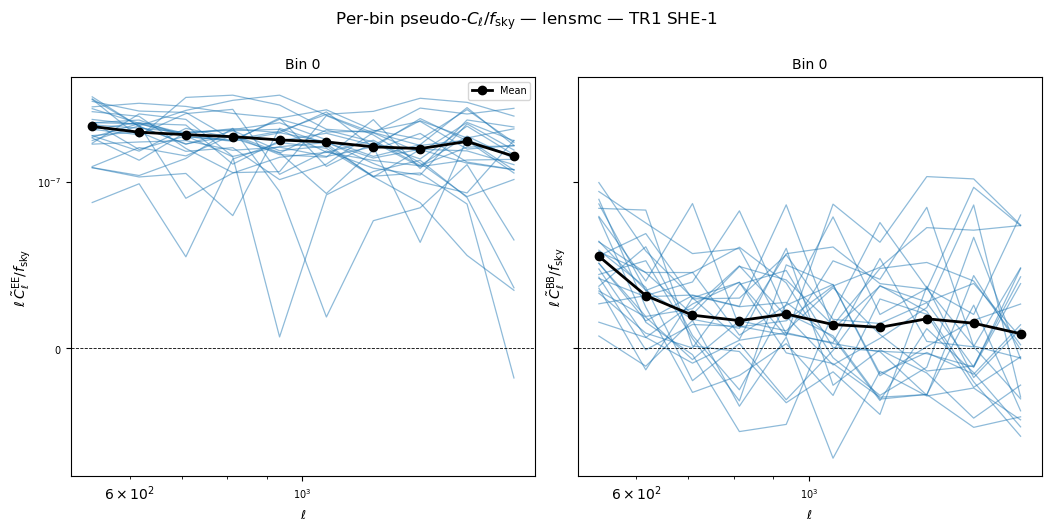

In [66]:
for method in methods:
    nrows = len(bins)
    fig, axes = plt.subplots(nrows, 2, figsize=(2 * 5.2, nrows * 5.2), sharey="row",
                             constrained_layout=True)

    for col, ibin in enumerate(bins):
        key        = ("SHE", "SHE", ibin, ibin)
        patch_fsky = fsky / n_patches

        # bin each patch's pseudo-Cl with ledges and rescale by fsky
        binned_ee = np.array([
            np.array(heracles.binned(all_data_cls[method][label][ibin], ledges)[key][0, 0])
            for label in range(1, n_patches + 1)
        ])
        binned_bb = np.array([
            np.array(heracles.binned(all_data_cls[method][label][ibin], ledges)[key][1, 1])
            for label in range(1, n_patches + 1)
        ])
        ell = heracles.binned(all_data_cls[method][1][ibin], ledges)[key].ell

        for row, (label_str, patch_arr) in enumerate([("EE", binned_ee), ("BB", binned_bb)]):
            ax = axes[row]
            for k in range(n_patches):
                ax.plot(ell, ell * patch_arr[k] / patch_fsky,
                        color='C0', alpha=0.5, lw=0.9, zorder=2)
            ax.plot(ell, ell * patch_arr.mean(axis=0) / patch_fsky, 'o-',
                    color="k", lw=2, zorder=5, label="Mean")
            ax.axhline(0, color="k", lw=0.6, ls="--")
            ax.set_xscale("log")
            ax.set_yscale("symlog", linthresh=1e-7)
            ax.set_xlabel(r"$\ell$", fontsize=9)
            if col == 0:
                ax.set_ylabel(r"$\ell\,\tilde{C}_\ell^{\rm " + label_str + r"} / f_{\rm sky}$", fontsize=10)
            ax.set_title(f"Bin {ibin}", fontsize=10)
            ax.tick_params(labelsize=7)
            if col == nrows - 1 and row == 0:
                ax.legend(fontsize=7, loc="upper right")

    fig.suptitle(
        r"Per-bin pseudo-$C_\ell / f_{\rm sky}$" + f" \u2014 {method} \u2014 TR1 SHE-1\n",
        fontsize=12,
    )
    plt.show()


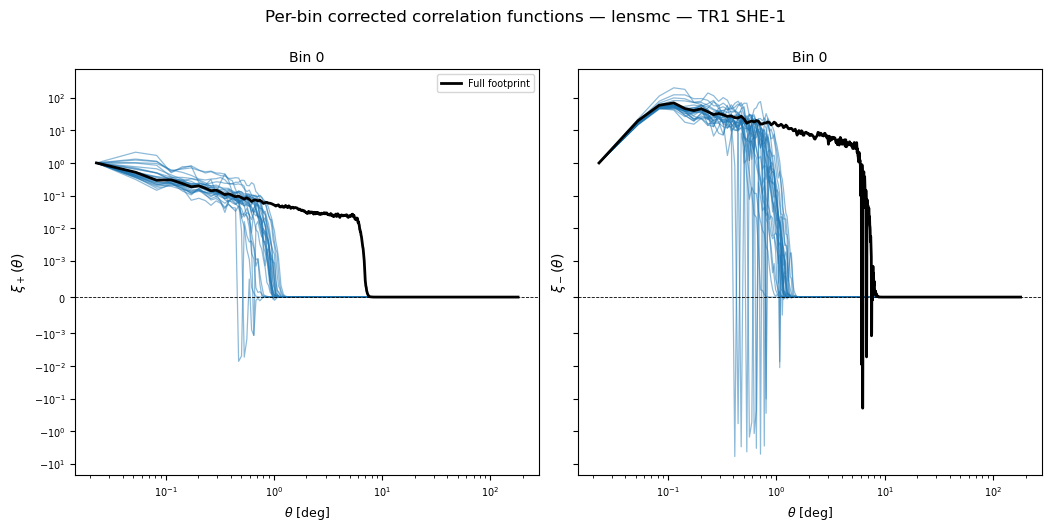

In [67]:
_sort      = np.argsort(theta_full)
theta_plot = theta_full[_sort]

for method in methods:
    nrows = len(bins)
    fig, axes = plt.subplots(nrows, 2, figsize=(2 * 5.2, nrows * 5.2), sharey="row",
                             constrained_layout=True)

    for col, ibin in enumerate(bins):
        full_xip  = np.array(all_corrf_full[method][ibin][0, 0])[_sort]
        full_xim  = np.array(all_corrf_full[method][ibin][1, 1])[_sort]
        patch_xip = np.array([np.array(all_corrf[method][label][ibin][0, 0])[_sort] for label in range(1, n_patches + 1)])
        patch_xim = np.array([np.array(all_corrf[method][label][ibin][1, 1])[_sort] for label in range(1, n_patches + 1)])

        for row, (label_str, full_arr, patch_arr) in enumerate([
            (r"$\xi_+(\theta)$", full_xip, patch_xip),
            (r"$\xi_-(\theta)$", full_xim, patch_xim),
        ]):
            ax = axes[row]
            for k in range(n_patches):
                ax.plot(theta_plot, patch_arr[k]/patch_arr[k][0], color='C0', alpha=0.5, lw=0.9, zorder=2)
            ax.plot(theta_plot, full_arr/full_arr[0], color="k", lw=2, zorder=5, label="Full footprint")
            ax.axhline(0, color="k", lw=0.6, ls="--")
            ax.set_xscale("log")
            ax.set_yscale("symlog", linthresh=1e-3)
            ax.set_xlabel(r"$\theta$ [deg]", fontsize=9)
            if col == 0:
                ax.set_ylabel(label_str, fontsize=10)
            ax.set_title(f"Bin {ibin}", fontsize=10)
            ax.tick_params(labelsize=7)
            if col == nrows - 1 and row == 0:
                ax.legend(fontsize=7, loc="upper right")

    fig.suptitle(
        f"Per-bin corrected correlation functions \u2014 {method} \u2014 TR1 SHE-1\n",
        fontsize=12,
    )
    plt.show()


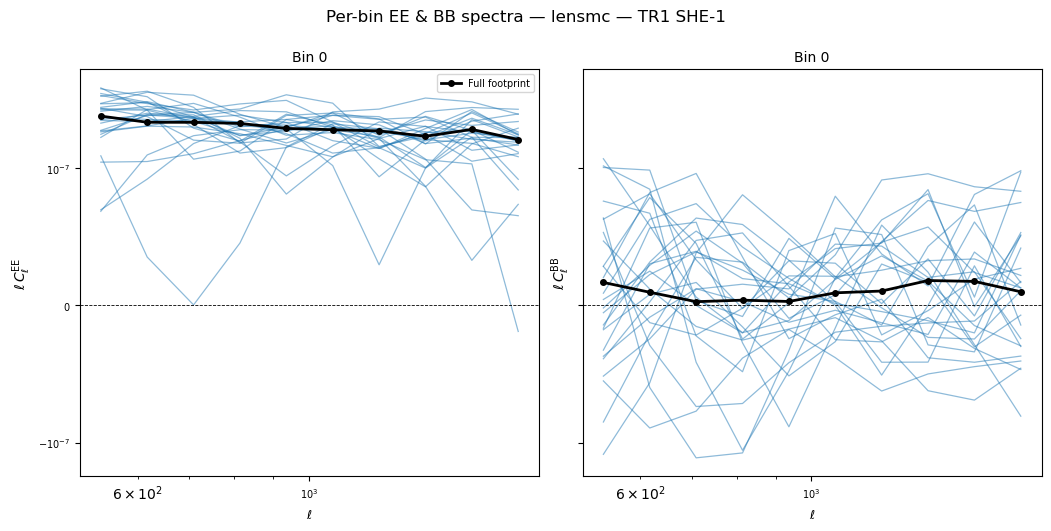

In [68]:
patch_colors = plt.cm.tab20(np.linspace(0, 1, n_patches))

for method in methods:
    nrows = len(bins)
    fig, axes = plt.subplots(nrows, 2, figsize=(2 * 5.2, nrows * 5.2), sharey="row",
                             constrained_layout=True)

    for col, ibin in enumerate(bins):
        cl_data = all_cl_full[method][ibin]

        for row, (component, comp_idx) in enumerate([
            ("EE", (0, 0)),
            ("BB", (1, 1)),
        ]):
            ax = axes[row]

            # Per-region deconvolved Cls
            patches = np.array([np.array(all_unmixed_binned[method][label][ibin][comp_idx]) for label in range(1, n_patches + 1)])
            for k in range(patches.shape[0]):
                ax.plot(lgrid, lgrid * patches[k],
                        color='C0', alpha=0.5, lw=0.9, zorder=2)

            # Full-footprint Cl
            ax.plot(lgrid, lgrid * np.array(cl_data[comp_idx]),
                    "o-", ms=4, lw=2, color="k", zorder=5, label="Full footprint")

            ax.axhline(0, color="k", lw=0.6, ls="--")
            ax.set_xscale("log")
            ax.set_yscale("symlog", linthresh=1e-7)
            ax.set_xlabel(r"$\ell$", fontsize=9)
            if col == 0:
                ax.set_ylabel(r"$\ell\,C_\ell^{\rm " + component + r"}$", fontsize=10)
            ax.set_title(f"Bin {ibin}", fontsize=10)
            ax.tick_params(labelsize=7)
            if col == nrows - 1 and row == 0:
                ax.legend(fontsize=7, loc="upper right")

    fig.suptitle(
        f"Per-bin EE & BB spectra \u2014 {method} \u2014 TR1 SHE-1\n",
        fontsize=12,
    )
    plt.show()


## 7. Leave-one-out $\chi^2$ outlier test

For each patch $k$ we compare its decoupled $C_\ell^{EE}$ to the mean of all
**other** patches:
$$\mu_{{-k}} = \frac{{1}}{{N-1}}\sum_{{j\neq k}} C_\ell^{{EE,j}}$$

The leave-one-out (LOO) $\chi^2$ is the Mahalanobis distance using the
covariance estimated from those same $N-1$ patches, so the outlier cannot
inflate its own reference or covariance.  Bins with $\ell < \ell_{{\min}}$
are excluded.

In [69]:
from scipy.stats import chi2 as chi2_dist

print(f"Using {nlbins} ell bins with ell >= {lmin}\n")

# all_chi2_loo[method][ibin], shape (N,)
all_chi2_loo = {method: {} for method in methods}

for method in methods:
    for ibin in bins:
        cls_chi2 = np.array([np.array(all_unmixed_binned[method][label][ibin][0, 0]) for label in range(1, n_patches + 1)])

        chi2_loo = np.zeros(n_patches)
        for k in range(n_patches):
            idx_rest    = [j for j in range(n_patches) if j != k]
            mu_loo      = cls_chi2[idx_rest].mean(axis=0)
            cov_loo     = np.cov(cls_chi2[idx_rest].T)
            diff        = cls_chi2[k] - mu_loo
            chi2_loo[k] = diff @ np.linalg.inv(cov_loo) @ diff

        all_chi2_loo[method][ibin] = chi2_loo
        n_out = (chi2_loo / nlbins > 3).sum()
        print(f"  [{method}] bin {ibin}: {n_out}/{n_patches} outliers  "
              f"(max reduced chi2 = {chi2_loo.max()/nlbins:.2f})")
    print()


Using 10 ell bins with ell >= 500

  [lensmc] bin 0: 6/25 outliers  (max reduced chi2 = 8.90)



## 8. B-mode null test

We test the null hypothesis $H_0: C_\ell^{BB} = 0$ at two levels:

1. **Full footprint** — is the full-survey BB spectrum consistent with zero?  
   We use the sample covariance of the per-patch BBs divided by $N$ as the
   covariance of the full-footprint estimator, then form
   $\chi^2 = \mathbf{C}_\ell^{BB\,T}\,\mathrm{Cov}^{-1}\,\mathbf{C}_\ell^{BB}$
   and compare to $\chi^2(p)$.

2. **Per patch** — which individual patches show significant non-zero BB?  
   For each patch $k$ we use the leave-one-out covariance of the BB spectra
   from the remaining $N-1$ patches as the noise model and test
   $\mathbf{C}_\ell^{BB,k}$ against zero.

In [70]:
print(f"B-mode null test  (H\u2080: C\u2113\u1d2e\u1d2e = 0,  {nlbins} dof)\n")

# all_chi2_bb_full[method][ibin]  = {"chi2": scalar}
# all_chi2_bb_patch[method][ibin] = array shape (N,)
all_chi2_bb_full  = {method: {} for method in methods}
all_chi2_bb_patch = {method: {} for method in methods}

for method in methods:
    for ibin in bins:
        cls_patches_bb = np.array([np.array(all_unmixed_binned[method][label][ibin][1, 1]) for label in range(1, n_patches + 1)])

        # Full-footprint test
        cov_bb_full  = np.cov(cls_patches_bb.T) / n_patches
        cl_bb_full   = np.array(all_cl_full[method][ibin][1, 1])
        chi2_bb_full = cl_bb_full @ np.linalg.inv(cov_bb_full) @ cl_bb_full
        all_chi2_bb_full[method][ibin] = {"chi2": chi2_bb_full}

        # Per-patch: test against zero using LOO cov from BB scatter
        chi2_bb_patch = np.zeros(n_patches)
        for k in range(n_patches):
            idx_rest         = [j for j in range(n_patches) if j != k]
            cov_loo_bb       = np.cov(cls_patches_bb[idx_rest].T)
            chi2_bb_patch[k] = cls_patches_bb[k] @ np.linalg.inv(cov_loo_bb) @ cls_patches_bb[k]
        all_chi2_bb_patch[method][ibin] = chi2_bb_patch

        n_out = (chi2_bb_patch / nlbins > 3).sum()
        print(f"  [{method}] bin {ibin}:  full \u03c7\u00b2/nlbins = {chi2_bb_full/nlbins:.3f}  |  "
              f"per-patch outliers = {n_out}/{n_patches}")
    print()


B-mode null test  (H₀: Cℓᴮᴮ = 0,  10 dof)

  [lensmc] bin 0:  full χ²/nlbins = 95.094  |  per-patch outliers = 4/25



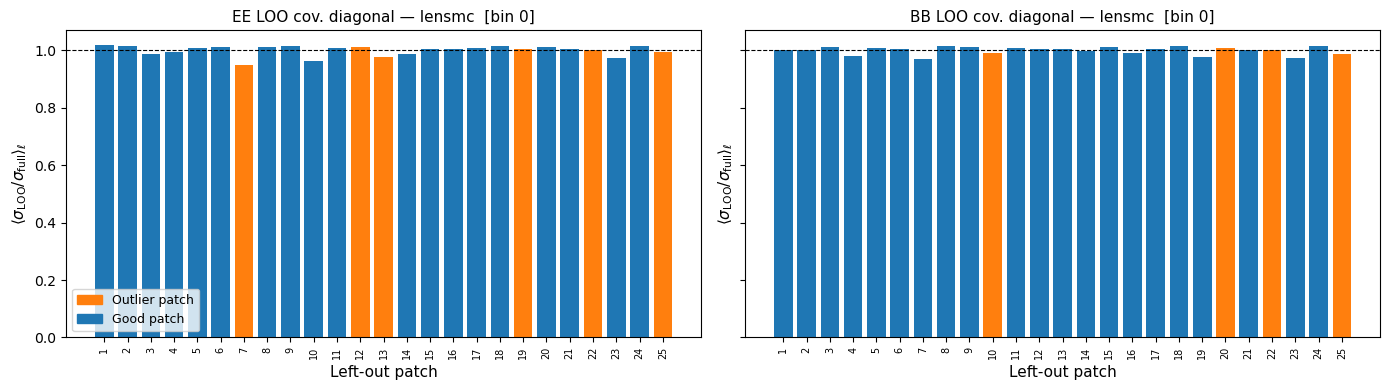

In [71]:
# LOO covariance diagonal diagnostic
# For each left-out patch k, compute the ell-averaged ratio of diag(Cov_{-k}) to diag(Cov_full).
# A ratio far from 1 signals that the covariance is driven by that single region.

for method in methods:
    for ibin in bins:
        cls_ee = np.array([np.array(all_unmixed_binned[method][label][ibin][0, 0]) for label in range(1, n_patches + 1)])
        cls_bb = np.array([np.array(all_unmixed_binned[method][label][ibin][1, 1]) for label in range(1, n_patches + 1)])

        fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
        patch_labels = [str(k + 1) for k in range(n_patches)]

        for ax, (label_str, cls, chi2_data) in zip(axes, [
            ("EE", cls_ee, all_chi2_loo[method][ibin]),
            ("BB", cls_bb, all_chi2_bb_patch[method][ibin]),
        ]):
            diag_full = np.sqrt(np.diag(np.cov(cls.T)))

            ratios = np.array([
                np.mean(np.sqrt(np.diag(np.cov(cls[[j for j in range(n_patches) if j != k]].T))) / diag_full)
                for k in range(n_patches)
            ])
            is_out = chi2_data / nlbins > 3
            colors = ["C1" if o else "C0" for o in is_out]

            ax.bar(patch_labels, ratios, color=colors)
            ax.axhline(1, color="k", lw=0.8, ls="--")
            ax.set_xlabel("Left-out patch", fontsize=11)
            ax.set_ylabel(r"$\langle\sigma_{\rm LOO} / \sigma_{\rm full}\rangle_\ell$", fontsize=11)
            ax.set_title(f"{label_str} LOO cov. diagonal \u2014 {method}  [bin {ibin}]", fontsize=11)
            ax.tick_params(axis="x", labelsize=7, rotation=90)

        handles = [
            plt.Rectangle((0, 0), 1, 1, color="C1", label="Outlier patch"),
            plt.Rectangle((0, 0), 1, 1, color="C0", label="Good patch"),
        ]
        axes[0].legend(handles=handles, fontsize=9)
        plt.tight_layout()
        plt.show()


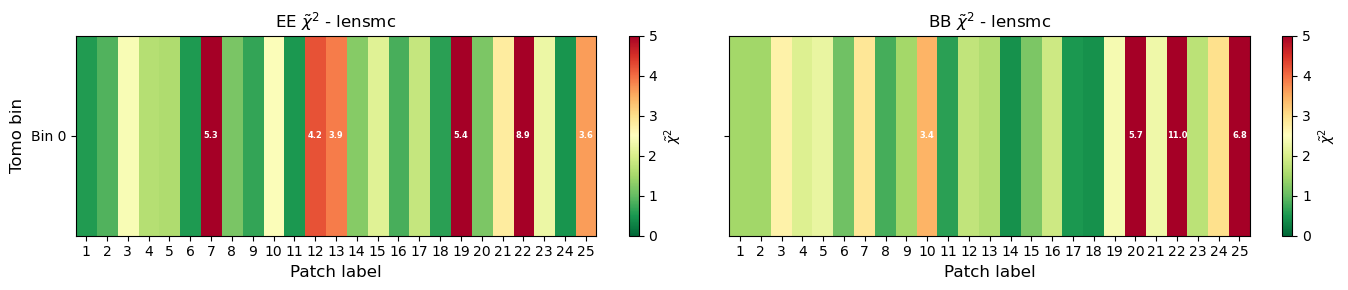

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(14, 3), sharey=True)

for row, method in enumerate(methods):
    for col, (label_str, chi2_data) in enumerate([
        ("EE", all_chi2_loo),
        ("BB", all_chi2_bb_patch),
    ]):
        ax = axes[col]
        mat = np.array([chi2_data[method][ibin] / nlbins for ibin in bins])
        im  = ax.imshow(mat, aspect="auto", cmap="RdYlGn_r", vmin=0, vmax=5,
                        extent=[0.5, n_patches + 0.5, len(bins) - 0.5, -0.5])
        ax.set_xlabel("Patch label", fontsize=12)
        if col == 0:
            ax.set_ylabel("Tomo bin", fontsize=12)
        ax.set_xticks(range(1, n_patches + 1))
        ax.set_yticks(range(len(bins)))
        ax.set_yticklabels([f"Bin {i}" for i in bins])
        ax.set_title(rf"{label_str} $\tilde{{\chi}}^2$ - {method}", fontsize=12)
        plt.colorbar(im, ax=ax, label=r"$\tilde{\chi}^2$")
        for bi, ibin in enumerate(bins):
            for k in range(n_patches):
                val = chi2_data[method][ibin][k] / nlbins
                if val > 3:
                    ax.text(k + 1, bi, f"{val:.1f}", ha="center", va="center",
                            fontsize=6, color="white", fontweight="bold")

plt.tight_layout()
plt.show()


/tmp/ipykernel_16380/90271142.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


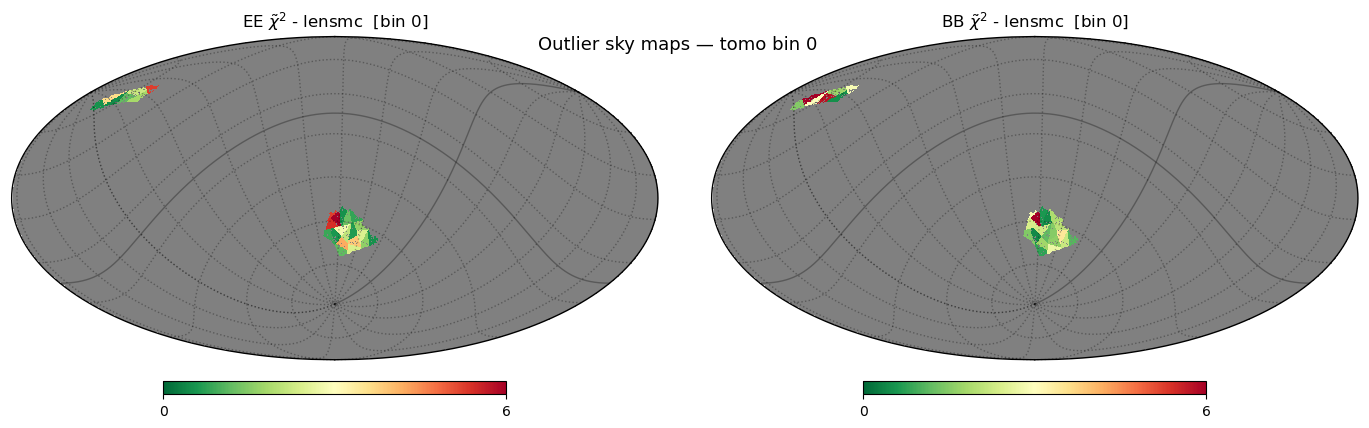

In [73]:
for ibin in bins:
    fig = plt.figure(figsize=(14, 8))
    for row, method in enumerate(methods):
        for col, (label_str, chi2_data) in enumerate([
            ("EE", all_chi2_loo),
            ("BB", all_chi2_bb_patch),
        ]):
            sky_chi2 = np.full(hp.nside2npix(nside), hp.UNSEEN, dtype=np.float64)
            for k in range(n_patches):
                sky_chi2[jkmap == k + 1] = chi2_data[method][ibin][k] / nlbins
            hp.mollview(
                sky_chi2, fig=fig, sub=(2, 2, row * 2 + col + 1),
                rot=(lon_c, lat_c, 0),
                title=rf"{label_str} $\tilde{{\chi}}^2$ - {method}  [bin {ibin}]",
                cmap="RdYlGn_r", min=0, max=6, notext=True,
            )
    hp.graticule(dpar=5, dmer=5, alpha=0.3)
    plt.suptitle(f"Outlier sky maps \u2014 tomo bin {ibin}", fontsize=13)
    plt.tight_layout()
    plt.show()


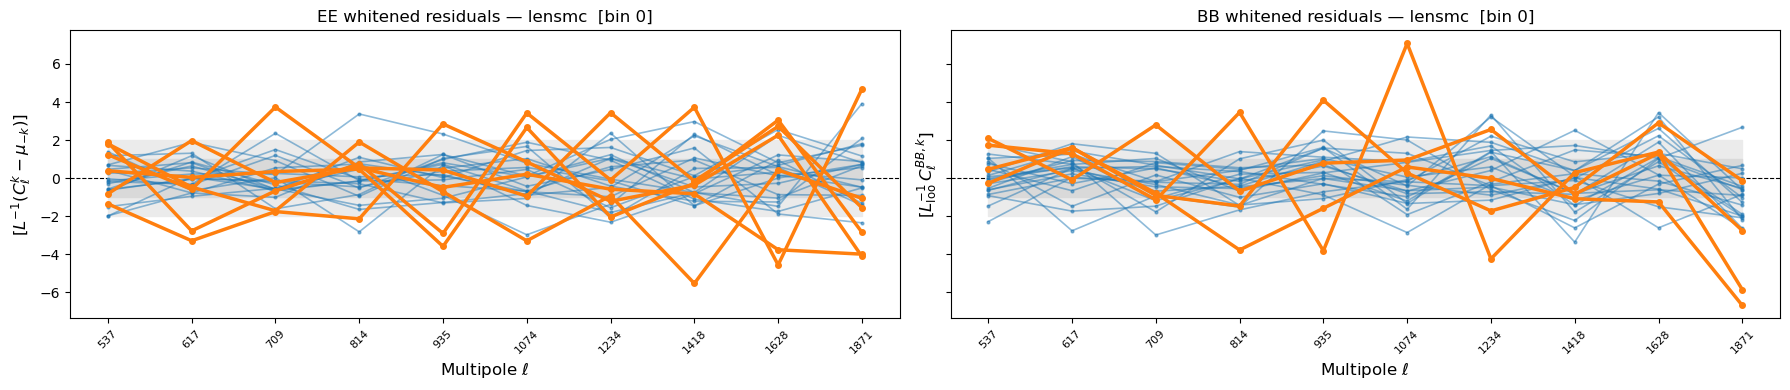

In [74]:
for ibin in bins:
    fig, axes = plt.subplots(1, 2, figsize=(18, 4), sharey="row")

    for row, method in enumerate(methods):
        for col, (label_str, comp_idx, chi2_data, null) in enumerate([
            ("EE", (0, 0), all_chi2_loo,      False),
            ("BB", (1, 1), all_chi2_bb_patch, True),
        ]):
            ax = axes[col]
            cls       = np.array([np.array(all_unmixed_binned[method][label][ibin][comp_idx]) for label in range(1, n_patches + 1)])
            chi2_vals = chi2_data[method][ibin]

            ax.axhline(0, color="k", lw=0.8, ls="--", zorder=0)
            ax.fill_between(range(nlbins), -1, 1, color="0.85", zorder=1, label=r"$1\sigma$")
            ax.fill_between(range(nlbins), -2, 2, color="0.92", zorder=0, label=r"$2\sigma$")

            for k in range(n_patches):
                idx_rest = [j for j in range(n_patches) if j != k]
                cov_loo  = np.cov(cls[idx_rest].T)
                L        = np.linalg.cholesky(cov_loo)
                mu       = np.zeros(nlbins) if null else cls[idx_rest].mean(axis=0)
                w        = np.linalg.solve(L, cls[k] - mu)

                is_out = chi2_vals[k] / nlbins > 3
                lbl    = f"Patch {k+1} (outlier)" if is_out else ("Good patches" if k == 0 else None)
                ax.plot(range(nlbins), w, color="C1" if is_out else "C0",
                        lw=2.5 if is_out else 1.2, alpha=1.0 if is_out else 0.5,
                        marker="o", ms=4 if is_out else 2,
                        zorder=5 if is_out else 2, label=lbl)

            ax.set_xticks(range(nlbins))
            ax.set_xticklabels([f"{l:.0f}" for l in lgrid], rotation=45, fontsize=8)
            ax.set_xlabel(r"Multipole $\ell$", fontsize=12)
            ax.set_ylabel(r"$[L^{-1}(C_\ell^k - \mu_{-k})]$" if not null
                          else r"$[L^{-1}_{\rm loo}\,C_\ell^{BB,k}]$", fontsize=12)
            ax.set_title(f"{label_str} whitened residuals \u2014 {method}  [bin {ibin}]", fontsize=12)
            #ax.set_yscale("symlog", linthresh=5E0)
            #ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()


## 9. BB Detection Significance via Jackknife Covariance

We estimate the covariance of the full-footprint $C_\ell^{BB}$ from a
leave-one-out (LOO) jackknife ensemble: each sample is the naturalspice-unmixed
spectrum obtained by summing the alms of all patches *except* patch $k$.


In [95]:
# Jackknife covariance for BB detection significance.
#
# Step 1: compute (or load from cache) ell-by-ell LOO unmixed Cls.
# Step 2: for each binning scheme and each patch selection (BB-based / EE-based),
#         compute the jackknife covariance and test the BB null hypothesis.

spin_she = fields["SHE"].spin  # 2
spin_wht = fields["WHT"].spin  # 0

lmin_wide   = 100
nlbins_wide = 10
ledges_wide = np.logspace(np.log10(lmin_wide), np.log10(lmax_out), nlbins_wide + 1)

# all_jk_chi2_bb[method][ibin][scheme]["full"/"clean_bb"/"clean_ee"] = results dict
all_jk_chi2_bb = {method: {} for method in methods}

# all_loo_cls_unbinned[method][ibin][k_p] = {key: ell-by-ell Result}
all_loo_cls_unbinned = {method: {ibin: {} for ibin in bins} for method in methods}

# ── Step 1: compute / load ell-by-ell LOO unmixed Cls ────────────────────────
for method in methods:
    for k_p in range(1, n_patches + 1):
        loo_cache = (f"{DATA_PRODUCTS_DIR}/{method}/"
                     f"loo_unmixed_remove_{k_p:03d}_lmax{lmax_out}"
                     f"_rcond_{rcond_str_full}_k_{k_full:.1f}.fits")

        if os.path.exists(loo_cache):
            saved = heracles.read(loo_cache)
            for ibin in bins:
                key = ("SHE", "SHE", ibin, ibin)
                all_loo_cls_unbinned[method][ibin][k_p] = {key: saved[key]}
        else:
            rest    = [j for j in range(1, n_patches + 1) if j != k_p]
            to_save = {}
            for ibin in bins:
                key   = ("SHE", "SHE", ibin, ibin)
                alm_d = sum(patch_data_alms[method][ibin][j] for j in rest)
                alm_m = sum(patch_mask_alms[method][ibin][j] for j in rest)
                ref_meta = dict(patch_data_alms[method][ibin][rest[0]].dtype.metadata or {})
                ref_meta["bias"] = b_all[method][ibin] * (n_patches - 1) / n_patches
                ref_meta["fsky"] = fsky * (n_patches - 1) / n_patches
                update_metadata(alm_d, **ref_meta)
                update_metadata(alm_m, spin=spin_wht)
                d_cls = heracles.angular_power_spectra({("SHE", ibin): alm_d})
                m_cls = heracles.angular_power_spectra({("WHT", ibin): alm_m})
                wd = heracles.cl2corr(heracles.binned(d_cls, np.arange(0, lmax_mask + 2)))
                wm = heracles.cl2corr(m_cls)
                for mk in list(wm.keys()):
                    a  = wm[mk].array
                    wm[mk] = replace(wm[mk], array=a * logistic(
                        np.log10(abs(a)), x0=np.log10(rcond_full * a.max()), k=k_full))
                corrf_l   = _naturalspice(wd, wm, fields)
                unmixed_l = heracles.binned(heracles.corr2cl(corrf_l), np.arange(0, lmax_out + 1))
                all_loo_cls_unbinned[method][ibin][k_p] = {key: unmixed_l[key]}
                to_save[key] = unmixed_l[key]
            heracles.write(loo_cache, to_save, clobber=True)

        print(f"  [{method}] LOO remove {k_p}/{n_patches}", end="\r", flush=True)
    print(f"  [{method}] LOO Cls done.          ")


def _compute_clean(method, ibin, good_patches, key):
    # Naturalspice on sum of good_patches alms (signal) plus a clean LOO
    # ensemble ('good patches minus k_p' for each k_p in good_patches).
    # Returns (unmixed_c, pseudo_cls_c, corrf_c, clean_loo_unbinned).
    n_g = len(good_patches)

    # signal
    alm_d_c = sum(patch_data_alms[method][ibin][j] for j in good_patches)
    alm_m_c = sum(patch_mask_alms[method][ibin][j] for j in good_patches)
    ref_c = dict(patch_data_alms[method][ibin][good_patches[0]].dtype.metadata or {})
    ref_c["bias"] = b_all[method][ibin] * n_g / n_patches
    ref_c["fsky"] = fsky * n_g / n_patches
    update_metadata(alm_d_c, **ref_c)
    update_metadata(alm_m_c, spin=spin_wht)
    d_cls_c = heracles.angular_power_spectra({("SHE", ibin): alm_d_c})
    m_cls_c = heracles.angular_power_spectra({("WHT", ibin): alm_m_c})
    wd_c = heracles.cl2corr(heracles.binned(d_cls_c, np.arange(0, lmax_mask + 2)))
    wm_c = heracles.cl2corr(m_cls_c)
    for mk in list(wm_c.keys()):
        a = wm_c[mk].array
        wm_c[mk] = replace(wm_c[mk], array=a * logistic(
            np.log10(abs(a)), x0=np.log10(rcond_full * a.max()), k=k_full))
    corrf_c   = _naturalspice(wd_c, wm_c, fields)
    unmixed_c = heracles.binned(heracles.corr2cl(corrf_c), np.arange(0, lmax_out + 1))

    # clean LOO ensemble
    clean_loo = {}
    for i, k_p in enumerate(good_patches):
        rest_c = [j for j in good_patches if j != k_p]
        alm_d_l = sum(patch_data_alms[method][ibin][j] for j in rest_c)
        alm_m_l = sum(patch_mask_alms[method][ibin][j] for j in rest_c)
        ref_l = dict(patch_data_alms[method][ibin][rest_c[0]].dtype.metadata or {})
        ref_l["bias"] = b_all[method][ibin] * (n_g - 1) / n_patches
        ref_l["fsky"] = fsky * (n_g - 1) / n_patches
        update_metadata(alm_d_l, **ref_l)
        update_metadata(alm_m_l, spin=spin_wht)
        d_cls_l = heracles.angular_power_spectra({("SHE", ibin): alm_d_l})
        m_cls_l = heracles.angular_power_spectra({("WHT", ibin): alm_m_l})
        wd_l = heracles.cl2corr(heracles.binned(d_cls_l, np.arange(0, lmax_mask + 2)))
        wm_l = heracles.cl2corr(m_cls_l)
        for mk in list(wm_l.keys()):
            a = wm_l[mk].array
            wm_l[mk] = replace(wm_l[mk], array=a * logistic(
                np.log10(abs(a)), x0=np.log10(rcond_full * a.max()), k=k_full))
        corrf_l   = _naturalspice(wd_l, wm_l, fields)
        unmixed_l = heracles.binned(heracles.corr2cl(corrf_l), np.arange(0, lmax_out + 1))
        clean_loo[k_p] = {key: unmixed_l[key]}
        print(f"      clean LOO {i+1}/{n_g}", end="\r", flush=True)
    print(f"      clean LOO done ({n_g} samples)          ")

    return unmixed_c, d_cls_c[key], corrf_c[key], clean_loo


# ── Step 2: covariances and chi2 for each binning scheme ─────────────────────
for method in methods:
    for ibin in bins:
        key     = ("SHE", "SHE", ibin, ibin)
        cov_key = ("SHE", "SHE", "SHE", "SHE", ibin, ibin, ibin, ibin)

        # patch selections: name -> per-patch chi2 array used to flag outliers
        selections = {
            "clean_bb": all_chi2_bb_patch[method][ibin],
            "clean_ee": all_chi2_loo[method][ibin],
        }

        # pre-compute signal + clean LOO for each selection
        sel_data = {}
        for sel_name, chi2_arr in selections.items():
            bad  = set(np.where(chi2_arr / nlbins > 3)[0] + 1)
            good = [p for p in range(1, n_patches + 1) if p not in bad]
            print(f"  [{method}] bin {ibin} [{sel_name}]: "
                  f"{len(bad)} bad patch(es) removed: {sorted(bad)}")
            if len(good) >= 3:
                unmixed_c, pseudo_c, corrf_c, clean_loo = _compute_clean(
                    method, ibin, good, key)
                sel_data[sel_name] = dict(good=good, unmixed_c=unmixed_c,
                                          pseudo_c=pseudo_c, corrf_c=corrf_c,
                                          clean_loo=clean_loo)
            else:
                sel_data[sel_name] = None

        all_jk_chi2_bb[method][ibin] = {}

        for scheme_name, _ledges, _nlbins in [
            ("narrow", ledges,      nlbins),
            ("wide",   ledges_wide, nlbins_wide),
        ]:
            # full-footprint covariance: LOO over all N patches
            loo_cls = {
                k_p: {k: heracles.binned(v, _ledges)
                      for k, v in all_loo_cls_unbinned[method][ibin][k_p].items()}
                for k_p in range(1, n_patches + 1)
            }
            jk_cov = dices.jackknife_covariance(loo_cls)
            cov_ee = np.array(jk_cov[cov_key][0, 0, 0, 0])
            cov_bb = np.array(jk_cov[cov_key][1, 1, 1, 1])

            binned_full = heracles.binned(
                heracles.binned(
                    heracles.corr2cl({key: all_corrf_full[method][ibin]}),
                    np.arange(0, lmax_out + 1),
                ),
                _ledges,
            )
            ell_full   = binned_full[key].ell
            cl_ee_full = np.array(binned_full[key][0, 0])
            cl_bb_full = np.array(binned_full[key][1, 1])
            chi2_full  = cl_bb_full @ np.linalg.inv(cov_bb) @ cl_bb_full
            pval_full  = chi2_dist.sf(chi2_full, df=_nlbins)
            print(f"    [{scheme_name}] full  chi2/dof={chi2_full/_nlbins:.3f}  p={pval_full:.4f}")

            scheme_res = {
                "full": dict(chi2=chi2_full, pval=pval_full,
                             cov_ee=cov_ee, cov_bb=cov_bb,
                             cl_ee=cl_ee_full, cl_bb=cl_bb_full,
                             ell=ell_full, good_patches=list(range(1, n_patches + 1)),
                             corrf=all_corrf_full[method][ibin]),
            }

            for sel_name, sd in sel_data.items():
                if sd is None:
                    scheme_res[sel_name] = dict(
                        chi2=np.nan, pval=np.nan,
                        cov_ee=None, cov_bb=None,
                        cl_ee=None, cl_bb=None, ell=None,
                        pseudo_cls=None, corrf=None, good_patches=[],
                    )
                    continue

                loo_clean = {
                    k_p: {k: heracles.binned(v, _ledges)
                          for k, v in sd["clean_loo"][k_p].items()}
                    for k_p in sd["good"]
                }
                jk_cov_c = dices.jackknife_covariance(loo_clean)
                cov_ee_c = np.array(jk_cov_c[cov_key][0, 0, 0, 0])
                cov_bb_c = np.array(jk_cov_c[cov_key][1, 1, 1, 1])

                binned_c = heracles.binned(sd["unmixed_c"], _ledges)
                ell_c    = binned_c[key].ell
                cl_ee_c  = np.array(binned_c[key][0, 0])
                cl_bb_c  = np.array(binned_c[key][1, 1])
                chi2_c   = cl_bb_c @ np.linalg.inv(cov_bb_c) @ cl_bb_c
                pval_c   = chi2_dist.sf(chi2_c, df=_nlbins)
                print(f"    [{scheme_name}] {sel_name}  chi2/dof={chi2_c/_nlbins:.3f}  p={pval_c:.4f}")

                scheme_res[sel_name] = dict(
                    chi2=chi2_c, pval=pval_c,
                    cov_ee=cov_ee_c, cov_bb=cov_bb_c,
                    cl_ee=cl_ee_c, cl_bb=cl_bb_c, ell=ell_c,
                    pseudo_cls=sd["pseudo_c"], corrf=sd["corrf_c"],
                    good_patches=sd["good"],
                )

            all_jk_chi2_bb[method][ibin][scheme_name] = scheme_res
        print()


  [lensmc] LOO Cls done.          
  [lensmc] bin 0 [clean_bb]: 4 bad patch(es) removed: [np.int64(10), np.int64(20), np.int64(22), np.int64(25)]
      clean LOO done (21 samples)          
  [lensmc] bin 0 [clean_ee]: 6 bad patch(es) removed: [np.int64(7), np.int64(12), np.int64(13), np.int64(19), np.int64(22), np.int64(25)]
      clean LOO done (19 samples)          
    [narrow] full  chi2/dof=2.264  p=0.0122
    [narrow] clean_bb  chi2/dof=0.658  p=0.7645
    [narrow] clean_ee  chi2/dof=1.160  p=0.3124
    [wide] full  chi2/dof=6.017  p=0.0000
    [wide] clean_bb  chi2/dof=6.498  p=0.0000
    [wide] clean_ee  chi2/dof=4.096  p=0.0000



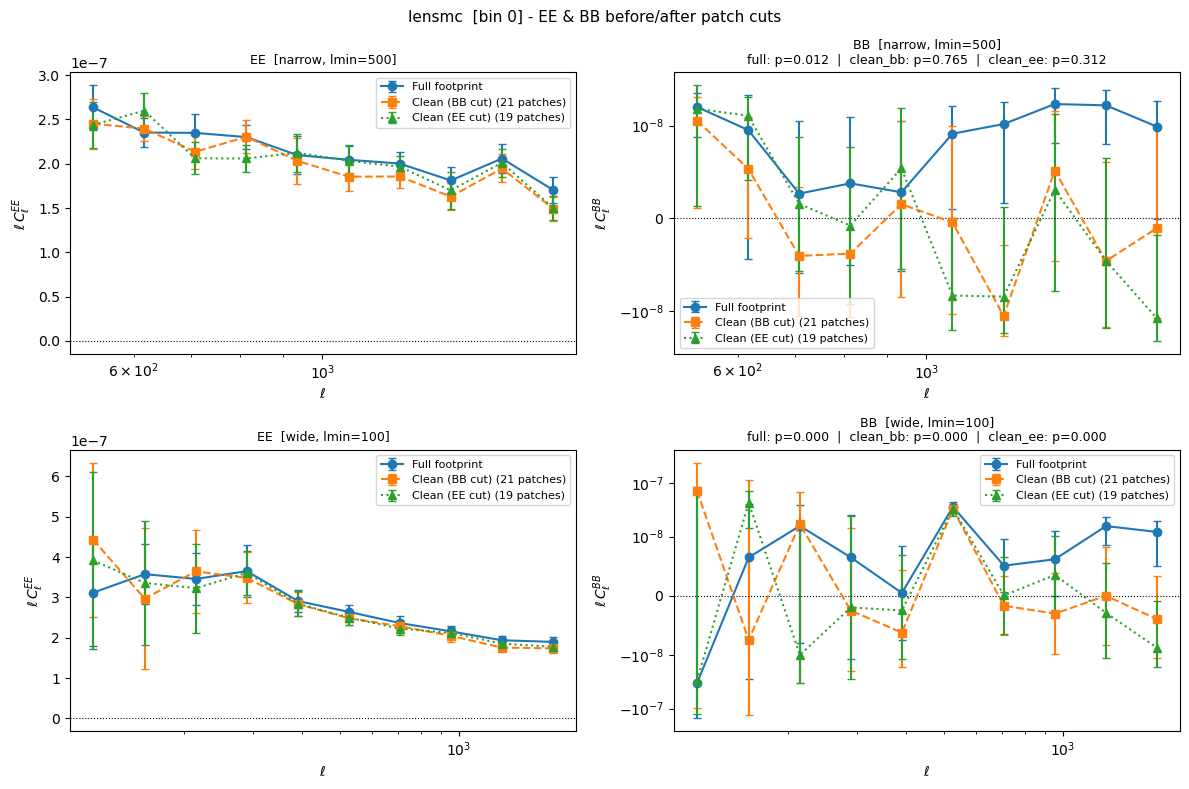

In [100]:
# Compare EE and BB before/after removing bad patches.
# Three lines per panel: full footprint, clean after BB cut, clean after EE cut.
# One row per binning scheme.
sel_styles = {
    "full":     dict(fmt="o-",  color="C0", label="Full footprint"),
    "clean_bb": dict(fmt="s--", color="C1", label="Clean (BB cut)"),
    "clean_ee": dict(fmt="^:",  color="C2", label="Clean (EE cut)"),
}

for method in methods:
    for ibin in bins:
        schemes = list(all_jk_chi2_bb[method][ibin].items())
        fig, axes = plt.subplots(len(schemes), 2,
                                  figsize=(12, 4 * len(schemes)), squeeze=False)

        for row, (scheme_name, scheme_res) in enumerate(schemes):
            lmin_label = lmin if scheme_name == "narrow" else lmin_wide
            for col, (comp, cl_key, cov_key) in enumerate([
                ("EE", "cl_ee", "cov_ee"),
                ("BB", "cl_bb", "cov_bb"),
            ]):
                ax = axes[row, col]
                pval_lines = []

                for sel_name, style in sel_styles.items():
                    res = scheme_res[sel_name]
                    if res[cl_key] is None:
                        continue
                    ell = res["ell"]
                    cl  = res[cl_key]
                    err = np.sqrt(np.diag(res[cov_key]))
                    n_g = len(res["good_patches"])
                    lbl = style["label"] if sel_name == "full" else f"{style['label']} ({n_g} patches)"
                    ax.errorbar(ell, ell * cl, yerr=ell * err,
                                fmt=style["fmt"], color=style["color"],
                                capsize=3, label=lbl)
                    if comp == "BB":
                        pval_lines.append(f"{sel_name}: p={res['pval']:.3f}")
                        ax.set_yscale("symlog", linthresh=1e-8)

                ax.axhline(0, color="k", lw=0.8, ls=":")
                ax.set_xlabel(r"$\ell$")
                ax.set_ylabel(rf"$\ell\,C_\ell^{{{comp}}}$")
                title = f"{comp}  [{scheme_name}, lmin={lmin_label}]"
                if pval_lines:
                    title += "\n" + "  |  ".join(pval_lines)
                ax.set_title(title, fontsize=9)
                ax.legend(fontsize=8)
                ax.set_xscale("log")
        fig.suptitle(f"{method}  [bin {ibin}] - EE & BB before/after patch cuts",
                     fontsize=11)
        plt.tight_layout()
        plt.show()


## 10. Overlap of Bad Patches with Processing Tiles

We load `patch_tiles_clean.fits` (nside=16384, NESTED, sparse) and downsample it to
the working nside using the NESTED property (low-res pixel = high-res pixel // ratio).
For each bad jackknife patch we then compute the fraction of its pixels that fall in
each processing tile, and produce a combined sky map plus an overlap bar chart.


Loaded processing-tile map from cache  (nside=2048)
Processing tiles in footprint: 50  ids=[  1   4   5  40  45  46  52  53  60  61  63  68  69  70  72  73  75  76
  77  86  87  93  94 102 103 108 109 112 113 118 119 124 125 127 128 133
 134 135 139 140 141 142 143 152 153 154 160 164 165 166]
JK boundary pixels: 84,807

[lensmc] bin 0  bad patches: [10, 20, 22, 25]
   Patch  Tile    % of patch in tile
      10    46                 99.5% <- implicated
      20    86                 47.7%
      20    87                 33.5%
      22    53                 53.4% <- implicated
      22    61                 25.9%
      25    86                 88.3% <- implicated
      25   165                  5.2%
  Implicated tiles: [46, 53, 86]


/tmp/ipykernel_16380/2732631594.py:132: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


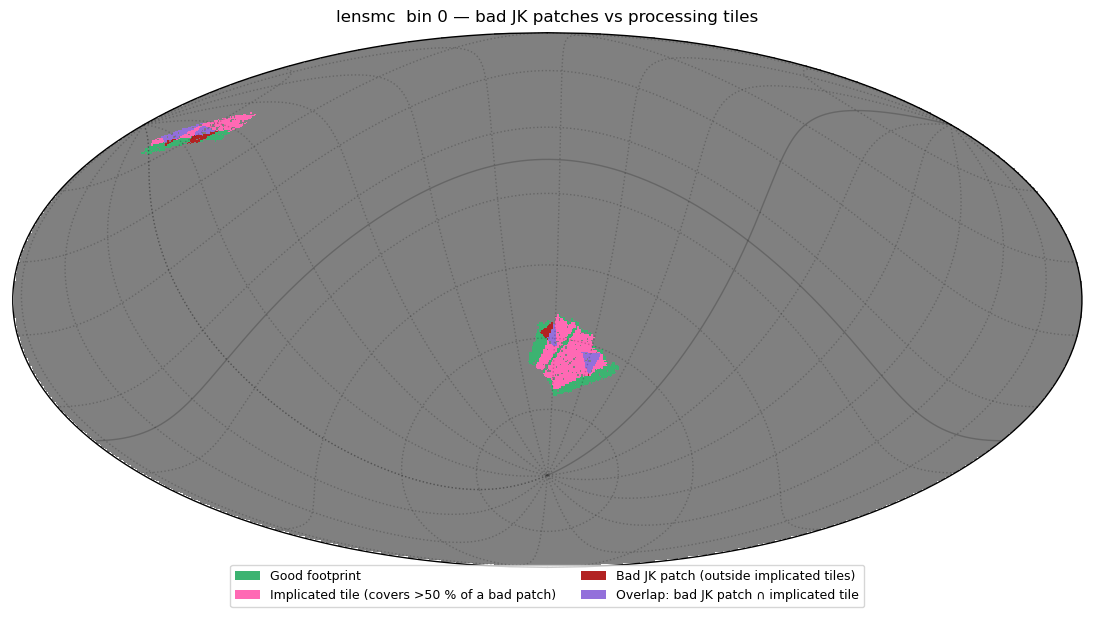

In [94]:
from astropy.io import fits as astropy_fits
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# ── 1. Downsample patch_tiles_clean to working nside ──────────────────────────────
TILES_FITS = f"{DATA_DIR}/patch_tiles_clean.fits"
tile_cache = f"{DATA_PRODUCTS_DIR}/patch_tiles_clean_nside{nside}.fits"

if os.path.exists(tile_cache):
    patch_tiles = hp.read_map(tile_cache, dtype=np.int16)
    print(f"Loaded processing-tile map from cache  (nside={nside})")
else:
    print("Downsampling patch_tiles_clean (nside=16384 NESTED sparse) ...", flush=True)
    with astropy_fits.open(TILES_FITS, memmap=True) as hdul:
        nside_orig       = int(hdul[1].header['NSIDE'])   # 16384
        ratio            = (nside_orig // nside) ** 2     # 64
        n_pix_out        = hp.nside2npix(nside)
        pixels_mm        = hdul[1].data['PIXEL']
        patches_mm       = hdul[1].data['PATCH']
        n_rows           = len(pixels_mm)
        patch_tiles_nest = np.zeros(n_pix_out, dtype=np.int16)
        chunk = 5_000_000
        for start in range(0, n_rows, chunk):
            end = min(start + chunk, n_rows)
            pix = np.array(pixels_mm[start:end], dtype=np.int64)
            pat = np.array(patches_mm[start:end], dtype=np.int16)
            patch_tiles_nest[pix // ratio] = pat
            print(f"  {end}/{n_rows}", end="\r", flush=True)
    patch_tiles = hp.reorder(patch_tiles_nest, n2r=True)
    hp.write_map(tile_cache, patch_tiles, dtype=np.int16, overwrite=True)
    print(f"\nDone.")

tile_ids       = np.unique(patch_tiles[patch_tiles > 0])
footprint_mask = jkmap > 0
n_pix          = hp.nside2npix(nside)
print(f"Processing tiles in footprint: {len(tile_ids)}  ids={tile_ids}")

# ── 2. Vectorised JK-region boundary detection ────────────────────────────────────
# A pixel is a boundary pixel if any of its 8 HEALPix neighbours has a different
# jkmap label (including pixels outside the footprint, which gives the outer edge).
fp_pix    = np.where(footprint_mask)[0]
neighbours = hp.get_all_neighbours(nside, fp_pix)   # shape (8, N_fp)
jk_fp      = jkmap[fp_pix]
is_boundary = np.zeros(len(fp_pix), dtype=bool)
for i in range(8):
    row   = neighbours[i]          # neighbour pixel index (-1 if none)
    valid = row >= 0
    is_boundary[valid] |= (jkmap[row[valid]] != jk_fp[valid])

jk_boundary_pix = fp_pix[is_boundary]
jk_bnd_theta, jk_bnd_phi = hp.pix2ang(nside, jk_boundary_pix)
print(f"JK boundary pixels: {len(jk_boundary_pix):,}")

# ── 3. Overlap map: green / pink / red / purple + JK grid overlay ─────────────────
#
#  A tile is 'implicated' if it covers >OVERLAP_THRESHOLD of any bad JK patch.
#
#  0 = green  : good footprint
#  1 = pink   : implicated tile pixels NOT in a bad JK patch
#  2 = red    : bad JK patch pixels NOT in an implicated tile
#  3 = purple : intersection — bad JK patch AND implicated tile
#
OVERLAP_THRESHOLD = 0.50

cmap_overlap = ListedColormap(['mediumseagreen', 'hotpink', 'firebrick', 'mediumpurple'])
legend_elements = [
    Patch(facecolor='mediumseagreen', label='Good footprint'),
    Patch(facecolor='hotpink',        label='Implicated tile (covers >50 % of a bad patch)'),
    Patch(facecolor='firebrick',      label='Bad JK patch (outside implicated tiles)'),
    Patch(facecolor='mediumpurple',   label='Overlap: bad JK patch ∩ implicated tile'),
]

for method in methods:
    for ibin in bins:
        chi2_patch = all_chi2_bb_patch[method][ibin]
        bad_labels = (np.where(chi2_patch / nlbins > 3)[0] + 1).tolist()
        bad_mask   = np.isin(jkmap, bad_labels)

        if not bad_labels:
            print(f"[{method}] bin {ibin}: no bad patches")
            continue

        print(f"\n[{method}] bin {ibin}  bad patches: {bad_labels}")
        print(f"  {'Patch':>6}  {'Tile':>4}  {'% of patch in tile':>20}")

        implicated_tiles = set()
        for k in bad_labels:
            pix_k   = np.where(jkmap == k)[0]
            n_k     = len(pix_k)
            tiles_k = patch_tiles[pix_k]
            for t in tile_ids:
                frac = (tiles_k == t).sum() / n_k
                if frac > 0.01:
                    flag = " <- implicated" if frac > OVERLAP_THRESHOLD else ""
                    print(f"  {k:>6}  {t:>4}  {frac*100:>19.1f}%{flag}")
                if frac > OVERLAP_THRESHOLD:
                    implicated_tiles.add(int(t))

        print(f"  Implicated tiles: {sorted(implicated_tiles)}")

        implicated_mask = (
            np.isin(patch_tiles, sorted(implicated_tiles))
            if implicated_tiles else np.zeros(n_pix, dtype=bool)
        )

        # Build colour-coded map
        color_map = np.full(n_pix, hp.UNSEEN)
        color_map[footprint_mask]                              = 0  # green
        color_map[footprint_mask & implicated_mask]            = 1  # pink
        color_map[footprint_mask & bad_mask]                   = 2  # red
        color_map[footprint_mask & bad_mask & implicated_mask] = 3  # purple

        fig = plt.figure(figsize=(12, 6))
        hp.mollview(
            color_map, fig=fig,
            rot=(lon_c, lat_c, 0),
            title=f"{method}  bin {ibin} — bad JK patches vs processing tiles",
            cmap=cmap_overlap, min=0, max=3,
            notext=True, cbar=False,
        )
        # Overlay JK-region grid as thin black dots along patch boundaries
        #hp.projscatter(
        #    jk_bnd_theta, jk_bnd_phi,
        #   lonlat=False, s=0.1, c='white', alpha=0.4, linewidths=0,
        #)
        hp.graticule(dpar=5, dmer=5, alpha=0.2)
        plt.gca().legend(
            handles=legend_elements,
            loc='lower center', bbox_to_anchor=(0.5, -0.08),
            ncol=2, fontsize=9, framealpha=0.8,
        )
        plt.tight_layout()
        plt.show()
